In [1]:
import os
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

In [2]:
train_dir = "train"
test_dir = "test"
valid_dir = "valid"

In [3]:
classes = sorted([
    c for c in os.listdir(train_dir)
    if c != ".DS_Store"
])

print("Number of classes:", len(classes))

Number of classes: 20


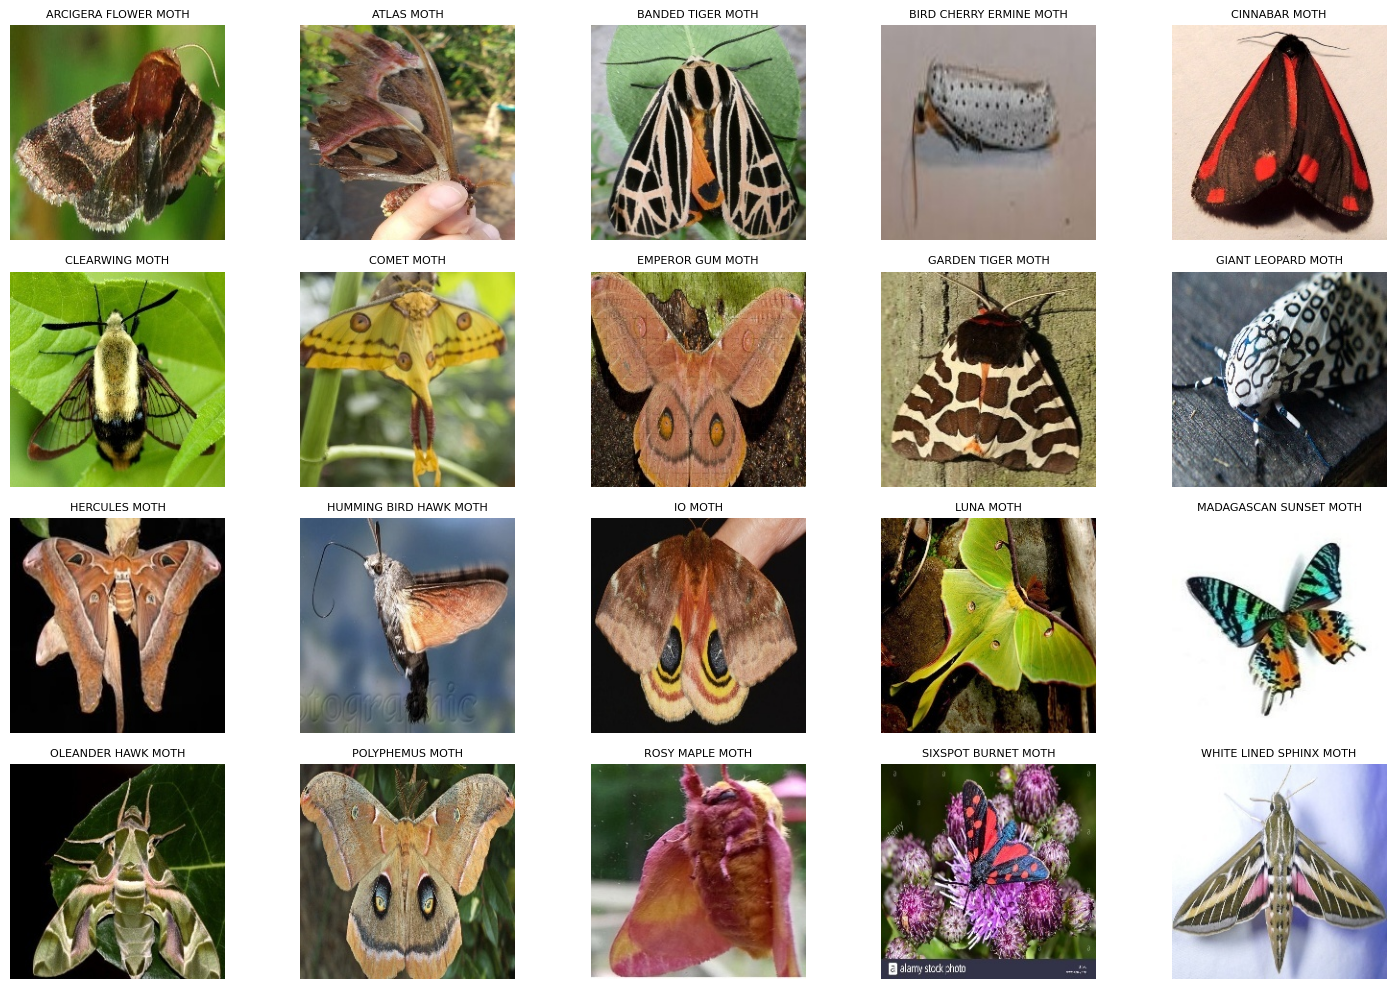

In [4]:
fig, axes = plt.subplots(4, 5, figsize=(15,10))

for ax, cls in zip(axes.flatten(), classes):

    folder = os.path.join(train_dir, cls)

    img_file = os.listdir(folder)[0]

    img_path = os.path.join(folder, img_file)

    img = Image.open(img_path)

    ax.imshow(img)
    ax.set_title(cls, fontsize=8)
    ax.axis("off")

plt.tight_layout()
plt.show()

In [5]:
sample_class = classes[0]

sample_image = os.listdir(
    os.path.join(train_dir, sample_class)
)[0]

img_path = os.path.join(
    train_dir,
    sample_class,
    sample_image
)

img = Image.open(img_path)

img_array = np.array(img)

print(img_array.shape)

(224, 224, 3)


In [6]:
sizes = []

for c in classes:

    folder = os.path.join(train_dir, c)

    for img_name in os.listdir(folder):

        img_path = os.path.join(folder, img_name)

        img = Image.open(img_path)

        sizes.append(img.size)

print(set(sizes))

{(224, 224)}


In [7]:
counts = {}

for c in classes:

    folder = os.path.join(train_dir, c)

    counts[c] = len(os.listdir(folder))

for cls, count in counts.items():

    print(cls, count)

ARCIGERA FLOWER MOTH 140
ATLAS MOTH 129
BANDED TIGER MOTH 136
BIRD CHERRY ERMINE MOTH 133
CINNABAR MOTH 131
CLEARWING MOTH 122
COMET MOTH 105
EMPEROR GUM MOTH 136
GARDEN TIGER MOTH 131
GIANT LEOPARD MOTH 129
HERCULES MOTH 137
HUMMING BIRD HAWK MOTH 143
IO MOTH 120
LUNA MOTH 117
MADAGASCAN SUNSET MOTH 123
OLEANDER HAWK MOTH 132
POLYPHEMUS MOTH 123
ROSY MAPLE MOTH 137
SIXSPOT BURNET MOTH 100
WHITE LINED SPHINX MOTH 143


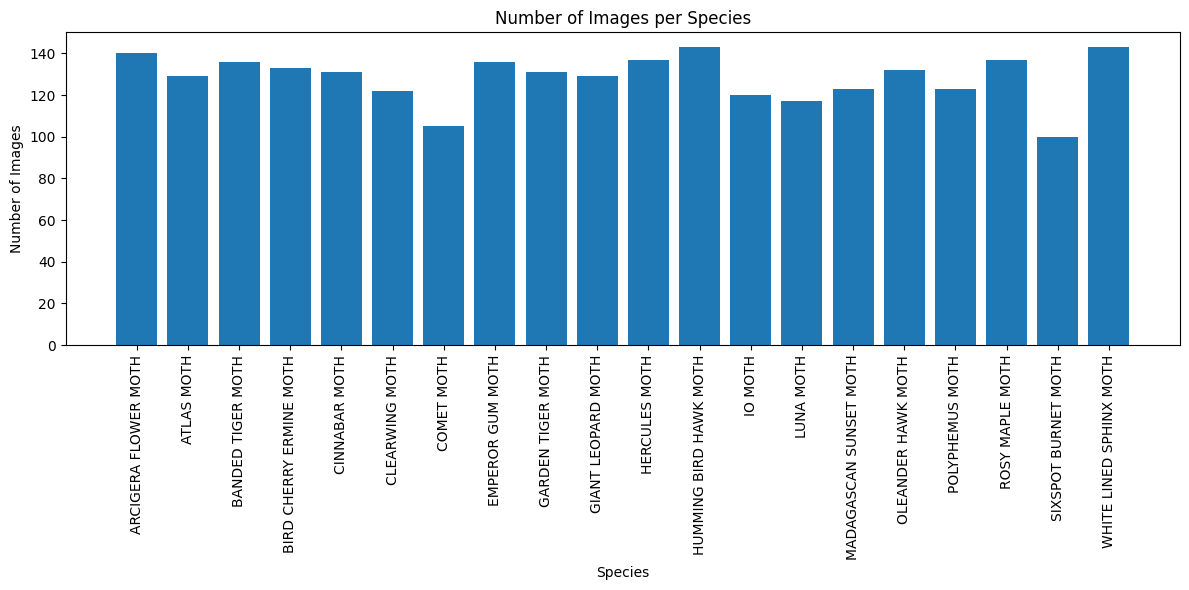

In [8]:
plt.figure(figsize=(12,6))

plt.bar(
    counts.keys(),
    counts.values()
)

plt.xticks(rotation=90)

plt.xlabel("Species")
plt.ylabel("Number of Images")

plt.title("Number of Images per Species")

plt.tight_layout()

plt.show()

In [9]:
total_images = sum(counts.values())

print("Total Training Images:", total_images)

Total Training Images: 2567


In [10]:
for split in ["train", "test", "valid"]:

    total = 0

    for c in os.listdir(split):

        if c == ".DS_Store":
            continue

        total += len(
            os.listdir(
                os.path.join(split, c)
            )
        )

    print(split, total)

train 2567
test 100
valid 100


In [11]:
for split in ["train", "test", "valid"]:

    cls = [
        c for c in os.listdir(split)
        if c != ".DS_Store"
    ][0]

    print(
        split,
        cls,
        len(
            os.listdir(
                os.path.join(split, cls)
            )
        )
    )

train COMET MOTH 105
test COMET MOTH 5
valid COMET MOTH 5


In [12]:
print(
    "Min images:",
    min(counts.values())
)

print(
    "Max images:",
    max(counts.values())
)

print(
    "Mean images:",
    np.mean(list(counts.values()))
)

print(
    "Std images:",
    np.std(list(counts.values()))
)

Min images: 100
Max images: 143
Mean images: 128.35
Std images: 11.239550702763879
